## 1. What this notebook computes

The earlier notebooks of this chapter studied one wave of dirac16complex with
momenta that do not change. In the author's metric they DO change: the three extra
times $x_5, x_6, x_7$ deflate exponentially (their scale factor is
$e^{-a_4}\sin^{1/6}z$, with $a_4$ increasing), and 3-space inflates (scale factor
$e^{a_4}\sin^{1/6}z$). A wave with a fixed coordinate momentum along an extra time
therefore has a frame momentum that GROWS like $e^{a_4}$. This notebook follows the
quantum structure of the chapter along the deflating history $a_4 = AHx_4$ of the
Revision Kohn-Sham record. It

- reads the scale factors from the Revision theory record and turns coordinate
  momenta into frame momenta;
- proves exactly that the mode Hamiltonian $h(x_4)$ of every instant satisfies
  $h(x_4)^2 = w(x_4)^2I_{16}$, and that its departure from Hermiticity and its
  mixing of the two eigenspaces of $B$ both grow like $e^{a_4}$;
- computes the exact time at which a wave with extra-time momentum turns from
  oscillation into growth, and shows that EVERY such wave reaches it;
- follows the eigenvalues and the Krein inertia of the eigenspaces through that
  time: inertia $(4, 4)$ before, Krein-neutral after;
- maps, for a whole range of extra-time momenta, which waves still have a real
  frequency at each time;
- shows that the good sector (no extra-time momentum) keeps a Hermitian mode
  Hamiltonian, the inertia $(4, 4)$ and a positive energy for every quantum at
  every time, with an energy that falls towards $m$ as 3-space inflates;
- checks that the masses $+m$ and $-m$ have the same onset of growth;
- draws five teaching figures.

Status of the inputs: the history $a_4 = AHx_4$ is a PRESCRIBED BACKGROUND (it is
not solved from the field equations for $a_4$), and every statement here is made in
the *local-frame model*: at each instant the coefficients of the wave equation are
evaluated at that instant and at one hidden position, as the Revision record does
for its statement that every extra-time mode eventually grows.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 10f (The Krein structure along the deflating history) is the file
`Revision/textbook/notebooks/10f_krein_along_history.ipynb` of the repository
Dirac_claude. Along the prescribed deflating history a4 = A H x4 of the Revision
Kohn-Sham record (A = H = m = 1) it takes the scale factors of the author's metric from
the Revision theory record, turns the coordinate momenta of a wave along x1 and along the
extra time x5 into frame momenta (the extra-time one grows like e to the a4 because the
extra times deflate), proves exactly that the local mode Hamiltonian of every instant
squares to w(x4)^2 times the identity and that its departure from Hermiticity and its
mixing of the two sectors of B grow like e to the a4, computes the exact time at which a
wave turns from oscillation to growth, follows the eigenvalues and the Krein inertia of
the eigenspaces through that time ((4, 4) before, Krein-neutral after), maps which waves
are still of real frequency at each time, shows that the good sector keeps a Hermitian
mode Hamiltonian, the Krein inertia (4, 4) and a positive instantaneous energy at every
time, checks that the masses +m and -m have the same onset, and draws five teaching
figures. It needs a computer with Windows 11, macOS or Linux, an internet connection for
the installation, the program Git, and Python 3.12 or newer (the notebooks were built
with Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
and matplotlib; the other packages run Jupyter, the program that shows and runs
notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 10f_krein_along_history.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 10f_krein_along_history.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
10f_krein_along_history.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/10f.captions.json`
- `Revision/textbook/figures/10f_1_hermiticity_defect.png`
- `Revision/textbook/figures/10f_2_eigenvalues_along_history.png`
- `Revision/textbook/figures/10f_3_inertia_along_history.png`
- `Revision/textbook/figures/10f_4_onset_map.png`
- `Revision/textbook/figures/10f_5_good_sector_energies.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 10f_5_good_sector_energies.png exists
    ALL 19 CHECKS PASSED (notebook 10f)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/10f_krein_along_history.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for parameters.json, field-theory.json or gammas.json: the notebook
  reads three files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository. Clone the repository
  again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 10f (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 10f (The Krein structure along the deflating history) is the file
# Revision/textbook/notebooks/10f_krein_along_history.ipynb of the repository
# Dirac_claude. Along the prescribed deflating history a4 = A H x4 of the Revision
# Kohn-Sham record (A = H = m = 1) it takes the scale factors of the author's metric from
# the Revision theory record, turns the coordinate momenta of a wave along x1 and along
# the extra time x5 into frame momenta (the extra-time one grows like e to the a4 because
# the extra times deflate), proves exactly that the local mode Hamiltonian of every
# instant squares to w(x4)^2 times the identity and that its departure from Hermiticity
# and its mixing of the two sectors of B grow like e to the a4, computes the exact time
# at which a wave turns from oscillation to growth, follows the eigenvalues and the Krein
# inertia of the eigenspaces through that time ((4, 4) before, Krein-neutral after), maps
# which waves are still of real frequency at each time, shows that the good sector keeps
# a Hermitian mode Hamiltonian, the Krein inertia (4, 4) and a positive instantaneous
# energy at every time, checks that the masses +m and -m have the same onset, and draws
# five teaching figures. It needs a computer with Windows 11, macOS or Linux, an internet
# connection for the installation, the program Git, and Python 3.12 or newer (the
# notebooks were built with Python 3.14.5) with these packages at exactly these versions:
# numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat
# 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself
# imports numpy, sympy and matplotlib; the other packages run Jupyter, the program that
# shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 10f_krein_along_history.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 10f_krein_along_history.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 10f_krein_along_history.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/10f.captions.json
# - Revision/textbook/figures/10f_1_hermiticity_defect.png
# - Revision/textbook/figures/10f_2_eigenvalues_along_history.png
# - Revision/textbook/figures/10f_3_inertia_along_history.png
# - Revision/textbook/figures/10f_4_onset_map.png
# - Revision/textbook/figures/10f_5_good_sector_energies.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 10f_5_good_sector_energies.png exists
#     ALL 19 CHECKS PASSED (notebook 10f)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/10f_krein_along_history.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for parameters.json, field-theory.json or gammas.json: the
#   notebook reads three files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository. Clone the
#   repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "10f"  # this notebook: chapter 10, example f


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 10f complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Scale factor** $f_a$: the factor by which the author's metric stretches the
  coordinate $x_a$; a coordinate distance $dx_a$ has the proper length $f_a\,dx_a$.
  For 3-space $f = e^{a_4}\sin^{1/6}z$, for the extra times $f = e^{-a_4}
  \sin^{1/6}z$.
- **Deflating history**: the time dependence $a_4 = AHx_4$ with $A = 1$; as $x_4$
  grows, 3-space inflates and the extra times deflate, both exponentially.
- **Coordinate momentum** $q_a$ and **frame momentum** $k_a$: a wave $e^{iq_ax_a}$
  has the coordinate momentum $q_a$; measured with proper lengths its momentum is
  $k_a = q_a/f_a$, the frame momentum.
- **Hidden position** $y$: the Kohn-Sham record measures the hidden direction by
  $y = \ln(\sin z)/(6H)$, so that $\sin^{1/6}z = e^{Hy}$; the patch end
  $z = \pi/2$ is $y = 0$, and $y < 0$ lies towards the tip.
- **Local-frame model**: at the instant $x_4$ and the position $y$ the wave equation
  is written with the coefficients of that instant and that position; the
  hidden-direction terms (studied in the notebook on the curved good sector) are
  left out.
- **Mode Hamiltonian** $h$: the $16 \times 16$ matrix with $i\,du/dx_4 = hu$; its
  eigenvalues $\pm w$ are the frequencies.
- **Onset time** $x_4^\ast$: the time at which $w^2$ changes from positive (the wave
  oscillates) to negative (the wave grows).
- **Hermitian part, anti-Hermitian part**: every matrix is $h = h_H + h_A$ with
  $h_H = \frac12(h + h^\dagger)$ Hermitian and $h_A = \frac12(h - h^\dagger)$
  anti-Hermitian ($h_A^\dagger = -h_A$).
- **Size of a matrix (spectral norm)**: the largest factor by which the matrix
  stretches the length of a column; in code `np.linalg.norm(M, 2)`.
- **Krein inertia, Krein-neutral**: as in the first notebook of this chapter, the
  numbers of positive, negative and zero eigenvalues of the Krein form $u^\dagger Bv$
  on a subspace; neutral means that the form vanishes on it.
- **Good sector**: waves without extra-time momentum, $q_5 = q_6 = q_7 = 0$.
- **Instantaneous**: computed with the coefficients of one instant, as if they did
  not change.

## 4. The physical and mathematical situation

**The wave equation of one instant, line by line.** The field equation of
dirac16complex in the author's metric (Revision theory record, $U = 0$) is

$$e^{-a_4}\sin^{-1/6}z\sum_{i=1}^{3}\gamma^{(x_i)}\partial_i\Psi + \gamma^{(x_4)}
\partial_4\Psi + e^{a_4}\sin^{-1/6}z\sum_{t=5}^{7}\gamma^{(x_t)}\partial_t\Psi +
\tan z\,\gamma^{(x_8)}\partial_8\Psi + 3H\gamma^{(x_8)}\Psi = m\Psi .$$

Each derivative $\partial_a$ is divided by the scale factor $f_a$ of its direction.
In the local-frame model take a wave $\Psi = u(x_4)\,e^{i(q_1x_1 + q_5x_5)}$ at one
hidden position and leave out the two hidden-direction terms. Then $\partial_1$
becomes $iq_1$ and $\partial_5$ becomes $iq_5$:

$$i k_1\gamma^{(x_1)}u + \gamma^{(x_4)}\frac{du}{dx_4} + ik_5\gamma^{(x_5)}u = mu,
\qquad k_1 = q_1e^{-a_4}\sin^{-1/6}z,\qquad k_5 = q_5e^{a_4}\sin^{-1/6}z .$$

Multiply from the left by $\gamma^{(x_4)}$, use $(\gamma^{(x_4)})^2 = -1$, solve for
$du/dx_4$ and multiply by $i$ (exactly the steps of the first notebook of this
chapter):

$$i\frac{du}{dx_4} = h(x_4)\,u,\qquad h(x_4) = -im\gamma^{(x_4)} -
k_1(x_4)\,\gamma^{(x_4)}\gamma^{(x_1)} - k_5(x_4)\,\gamma^{(x_4)}\gamma^{(x_5)} .$$

With $\sin^{1/6}z = e^{Hy}$ and $a_4 = AHx_4$ the frame momenta are
$k_1 = q_1e^{-AHx_4 - Hy}$, which SHRINKS (3-space inflates), and
$k_5 = q_5e^{AHx_4 - Hy}$, which GROWS (the extra times deflate).

**The squared frequency.** By the identity $h^2 = w^2I_{16}$ of the first notebook
of this chapter, at every instant

$$w(x_4)^2 = m^2 + k_1^2 - k_5^2 = m^2 + q_1^2e^{-2AHx_4 - 2Hy} -
q_5^2e^{2AHx_4 - 2Hy} .$$

For $A > 0$ the second term falls and the third grows in size, so $w^2$ falls all
the time; if $q_5 \neq 0$ it becomes negative after a finite time.

**The onset time, line by line.** Write $X = e^{2AHx_4} > 0$ and $c = e^{-2Hy}$.
The condition $w^2 = 0$ reads $m^2 + q_1^2c/X - q_5^2cX = 0$. Multiply by $X$:

$$q_5^2c\,X^2 - m^2X - q_1^2c = 0 .$$

This is a quadratic equation for $X$; its only positive root is

$$X^\ast = \frac{m^2 + \sqrt{m^4 + 4q_1^2q_5^2c^2}}{2q_5^2c},\qquad
x_4^\ast = \frac{\ln X^\ast}{2AH} .$$

(The other root has the minus sign in front of the square root; it is negative, or
zero when $q_1 = 0$, because the square root is at least $m^2$, while
$X = e^{2AHx_4}$ is always positive.) For $q_1 = 0$ and $y = 0$ this is
$X^\ast = m^2/q_5^2$, so $x_4^\ast = \ln(m/q_5)/(AH)$: the onset comes when the
growing frame momentum $k_5$ reaches the mass.

**Hermitian and anti-Hermitian parts.** The matrices $-i\gamma^{(x_4)}$ and
$\gamma^{(x_4)}\gamma^{(x_1)}$ are Hermitian and commute with $B$, while
$\gamma^{(x_4)}\gamma^{(x_5)}$ is anti-Hermitian and anticommutes with $B$ (first
notebook of this chapter). Hence $h_A = -k_5\gamma^{(x_4)}\gamma^{(x_5)}$, and since
$(\gamma^{(x_4)}\gamma^{(x_5)})^2 = -(\gamma^{(x_4)})^2(\gamma^{(x_5)})^2 = -I$,

$$h_A^\dagger h_A = -h_A^2 = k_5^2 I_{16} .$$

So $h_A$ stretches every column by exactly the factor $k_5$: the size of the
anti-Hermitian part is $k_5 = q_5e^{AHx_4 - Hy}$. In the same way
$Bh - hB = 2Bh_A$ has the size $2k_5$ ($B$ keeps lengths, because $B^\dagger B =
B^2 = I$). Both grow exponentially with the deflation; both vanish at every time in
the good sector, $q_5 = 0$.

**Krein inertia at each instant.** At each instant $h(x_4)$ is the mode Hamiltonian
of the first notebook of this chapter with real frame momenta, so the Revision
proof applies instant by instant: while $w^2 > 0$ each eigenspace has Krein inertia
$(4, 4)$; once $w^2 < 0$ each eigenspace is Krein-neutral.

## 5. The deflating history of the Revision record

The next cell reads the parameters of the Revision Kohn-Sham record: the constant
$H$, the mass $m$, the history constant $A$ and the five slices $a_{4,0}$ at which
that record computes its instantaneous Kohn-Sham states. It prints the first
sentence of the record's own statement of the status of the history and checks the
values $A = H = m = 1$. It also defines `check_record` (the PASS line and the line
naming the reproduced Revision record are printed in one piece, because Jupyter
sends printed text to the screen in pieces whose boundaries depend on timing) and
the colours of the figures.

In [2]:
import contextlib  # lets a block of code print into a text buffer
import io  # the text buffer
import sys  # the screen output, sys.stdout

import numpy as np  # numbers, arrays and matrices
import sympy as sp  # exact algebra with symbols


def check_record(condition, name, record):
    """check(condition, name, record=record), printed in one piece."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):  # what check prints goes to buffer
        check(condition, name, record=record)
    sys.stdout.write(buffer.getvalue())  # one single piece of output


BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
parameters = json.loads(repository_file(
    "Revision/kohn_sham/results/parameters.json").read_text(encoding="utf-8"))
H = parameters["physics"]["H"]  # the author's constant H
mass = parameters["physics"]["m"]  # the mass m
A = parameters["physics"]["historyA"]  # the history a4 = A H x4
slices = parameters["physics"]["slicesA4"]  # the values a4,0 of the record
say("status of the history: "
    + parameters["conventions"]["history"].split(": ")[0] + ".")
say(f"slices a4,0 of the Kohn-Sham record: {slices}")
check_record(A == 1.0 and H == 1.0 and mass == 1.0,
             "the deflating history a4 = A H x4 with A = 1, H = 1, m = 1",
             record="Revision/kohn_sham/results/parameters.json, physics.historyA, "
                    "physics.H, physics.m")


def a4_of(x4):
    """The prescribed deflating history a4 = A H x4."""
    return A * H * x4

status of the history: PRESCRIBED BACKGROUND.
slices a4,0 of the Kohn-Sham record: [0.0, 0.5, 1.0, 1.5, 2.0]
PASS the deflating history a4 = A H x4 with A = 1, H = 1, m = 1
     reproduces Revision/kohn_sham/results/parameters.json, physics.historyA, physics.H,
    physics.m


## 6. Frame momenta from the scale factors of the record

The Revision theory record `Revision/theory/field-theory.json` stores the scale
factors $f_a$ of the eight directions (formula key `vielbein_diagonal`) in the
notation of the Wolfram Language, for example `E^a4[x4]*Sin[6*H*x8]^(1/6)`. The
next cell translates this text into sympy (`E^a4[x4]` becomes `exp(a4)`,
`Sin[6*H*x8]` becomes `sin(z)`, `^` becomes `**`, curly brackets become square
brackets), and checks EXACTLY that it equals $e^{a_4}\sin^{1/6}z$ for $x_1, x_2,
x_3$, 1 for $x_4$, $e^{-a_4}\sin^{1/6}z$ for the extra times and $\cot z$ for
$x_8$. Then it defines the frame momenta $k_1 = q_1/f_1$ and $k_5 = q_5/f_5$ at
the time $x_4$ and the hidden position $y$ (with $\sin^{1/6}z = e^{Hy}$).

In [3]:
theory = json.loads(repository_file("Revision/theory/field-theory.json").read_text(
    encoding="utf-8"))
text = next(f["wl"] for f in theory["formulas"] if f["key"] == "vielbein_diagonal")
a4_symbol, z_symbol = sp.symbols("a4 z", real=True)
translated = (text.replace("E^a4[x4]", "exp(a4)").replace("Sin[6*H*x8]", "sin(z)")
              .replace("Cot[6*H*x8]", "cot(z)").replace("^", "**")
              .replace("{", "[").replace("}", "]"))
f_record = sp.sympify(translated, locals={"a4": a4_symbol, "z": z_symbol})
sixth_root = sp.sin(z_symbol) ** sp.Rational(1, 6)  # sin(z)^(1/6)
f_expected = ([sp.exp(a4_symbol) * sixth_root] * 3 + [sp.Integer(1)]
              + [sp.exp(-a4_symbol) * sixth_root] * 3 + [sp.cot(z_symbol)])
same = all(sp.simplify(r - e) == 0 for r, e in zip(f_record, f_expected))
say(f"scale factor of x1: {f_record[0]}")
say(f"scale factor of x5: {f_record[4]}")
check_record(len(f_record) == 8 and same,
             "the record's scale factors: e^a4 sin^(1/6) z (3-space), e^-a4 ... (x5-x7)",
             record="Revision/theory/field-theory.json, formula vielbein_diagonal")


def frame_momenta(x4, q1, q5, y):
    """(k_1, k_5) of the wave exp(i (q1 x1 + q5 x5)) at time x4 and position y."""
    root = np.exp(H * y)  # sin(z)^(1/6) = e^(H y)
    k1 = q1 / (np.exp(a4_of(x4)) * root)  # q1 / f_1: shrinks, 3-space inflates
    k5 = q5 / (np.exp(-a4_of(x4)) * root)  # q5 / f_5: grows, extra times deflate
    return k1, k5

scale factor of x1: exp(a4)*sin(z)**(1/6)
scale factor of x5: exp(-a4)*sin(z)**(1/6)
PASS the record's scale factors: e^a4 sin^(1/6) z (3-space), e^-a4 ... (x5-x7)
     reproduces Revision/theory/field-theory.json, formula vielbein_diagonal


## 7. The mode Hamiltonian of each instant, exactly

The next cell reads the gammas, builds $B$ and the chirality $\Gamma$, and defines
the mode Hamiltonian `mode_hamiltonian(x4, q1, q5, y, m)` of Section 4 as a numpy
matrix. Then it repeats the algebra of Section 4 EXACTLY with sympy, with symbols
for $m$, $q_1$, $q_5$, $H$, $y$ and the time $x_4$ (so the statements hold at every
instant and every position):

- $h(x_4)^2 = (m^2 + q_1^2e^{-2a_4 - 2Hy} - q_5^2e^{2a_4 - 2Hy})I_{16}$;
- the anti-Hermitian part is $h_A = -k_5\gamma^{(x_4)}\gamma^{(x_5)}$ and
  $h_A^\dagger h_A = k_5^2I_{16}$;
- $Bh - hB = 2Bh_A$;
- in the good sector ($q_5 = 0$) $h$ is Hermitian and commutes with $B$ at every
  time.

In [4]:
fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=float) for a in range(1, 9)}
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]  # the author's sigma16
B = -1j * (C @ gamma[4])  # B = -i C gamma^(x4)
Gamma = (gamma[8] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5]
         @ gamma[6] @ gamma[7])  # the chirality matrix


def mode_hamiltonian(x4, q1, q5, y, m=mass):
    """h(x4) = -i m g4 - k1 g4 g1 - k5 g4 g5 with the frame momenta of time x4."""
    k1, k5 = frame_momenta(x4, q1, q5, y)
    return (-1j * m * gamma[4] - k1 * (gamma[4] @ gamma[1])
            - k5 * (gamma[4] @ gamma[5]))


def w_squared(x4, q1, q5, y, m=mass):
    """w^2 = m^2 + k1^2 - k5^2 at the time x4."""
    k1, k5 = frame_momenta(x4, q1, q5, y)
    return m ** 2 + k1 ** 2 - k5 ** 2


g = {a: sp.Matrix(fixture["gamma"][a - 1]) for a in range(1, 9)}  # exact gammas
B_exact = -sp.I * g[8] * g[1] * g[2] * g[3] * g[4]
m_s, q1_s, q5_s, y_s = sp.symbols("m q1 q5 y", real=True)
x4_s, H_s = sp.symbols("x4 H", positive=True)
a4_s = A * H_s * x4_s  # the history, with the record's A = 1
k1_s = q1_s * sp.exp(-a4_s - H_s * y_s)  # frame momentum along x1
k5_s = q5_s * sp.exp(a4_s - H_s * y_s)  # frame momentum along x5
h_s = -sp.I * m_s * g[4] - k1_s * g[4] * g[1] - k5_s * g[4] * g[5]
zero = sp.zeros(16, 16)
w2_s = m_s ** 2 + k1_s ** 2 - k5_s ** 2
square_ok = (h_s * h_s - w2_s * sp.eye(16)).applyfunc(sp.expand) == zero
h_A = ((h_s - h_s.H) / 2).applyfunc(sp.expand)  # the anti-Hermitian part
part_ok = (h_A + k5_s * g[4] * g[5]).applyfunc(sp.expand) == zero
size_ok = (h_A.H * h_A - k5_s ** 2 * sp.eye(16)).applyfunc(sp.expand) == zero
mixing_ok = (B_exact * h_s - h_s * B_exact - 2 * B_exact * h_A).applyfunc(
    sp.expand) == zero
good = h_s.subs(q5_s, 0)  # the good sector
good_ok = ((good - good.H).applyfunc(sp.expand) == zero
           and (B_exact * good - good * B_exact).applyfunc(sp.expand) == zero)
check(square_ok, "exact: h(x4)^2 = (m^2 + k1^2 - k5^2) I at every instant")
check(part_ok and size_ok and mixing_ok,
      "exact: h_A = -k5 g4 g5, h_A^dagger h_A = k5^2 I, B h - h B = 2 B h_A")
check_record(good_ok,
             "exact: good sector, h(x4) Hermitian and commuting with B at all times",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_spectrum_and_B_sectors")

PASS exact: h(x4)^2 = (m^2 + k1^2 - k5^2) I at every instant
PASS exact: h_A = -k5 g4 g5, h_A^dagger h_A = k5^2 I, B h - h B = 2 B h_A
PASS exact: good sector, h(x4) Hermitian and commuting with B at all times
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_spectrum_and_B_sectors


## 8. Departure from Hermiticity and mixing of the two sectors of $B$

The next cell measures, with numbers, the size of the anti-Hermitian part $h_A$ and
of the commutator $Bh - hB$ (`np.linalg.norm(M, 2)`, the largest stretching factor)
for three extra-time momenta $q_5 = 0.01$, $0.05$, $0.2$ (with $q_1 = 0.5$, $y = 0$)
at the times $x_4 = 0, 0.5, \dots, 6$, compares them with the formulas $k_5 =
q_5e^{a_4}$ and $2k_5$ of Section 4, and draws them on a logarithmic scale, where an
exponential is a straight line. In the good sector both sizes are 0 at every time.

RESULT largest relative difference from k5 and 2 k5 = 0.0e+00
PASS sizes of h_A and of B h - h B are k5 = q5 e^a4 and 2 k5; zero if q5 = 0


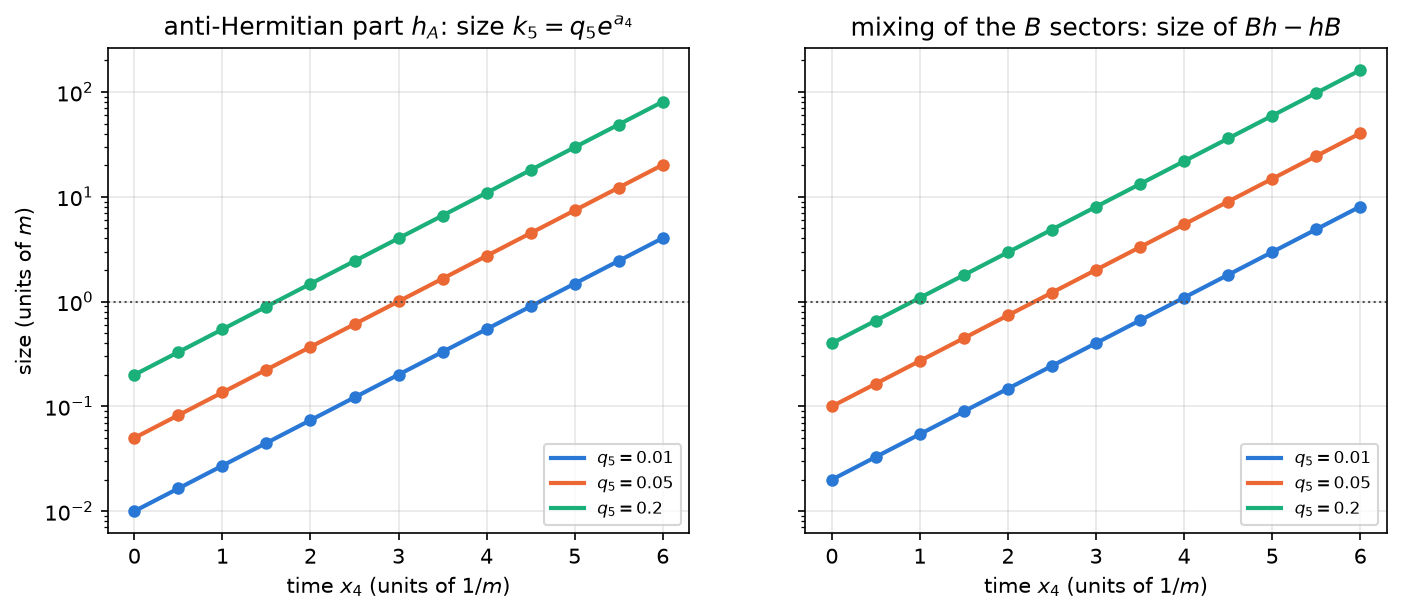

Figure 10f.1 saved as Revision/textbook/figures/10f_1_hermiticity_defect.png


In [5]:
times = np.linspace(0.0, 6.0, 13)  # 0, 0.5, ..., 6
curve_times = np.linspace(0.0, 6.0, 241)
measured, worst = {}, 0.0
for q5 in (0.01, 0.05, 0.2):
    sizes = []
    for x4 in times:
        h = mode_hamiltonian(x4, 0.5, q5, 0.0)
        h_anti = (h - h.conj().T) / 2
        sizes.append((np.linalg.norm(h_anti, 2), np.linalg.norm(B @ h - h @ B, 2)))
        k5 = frame_momenta(x4, 0.5, q5, 0.0)[1]
        worst = max(worst, abs(sizes[-1][0] - k5) / k5,
                    abs(sizes[-1][1] - 2 * k5) / (2 * k5))
    measured[q5] = np.array(sizes)
good_sizes = [np.linalg.norm(mode_hamiltonian(x4, 0.5, 0.0, 0.0)
                             - mode_hamiltonian(x4, 0.5, 0.0, 0.0).conj().T, 2)
              for x4 in times]
report("largest relative difference from k5 and 2 k5", f"{worst:.1e}")
check(worst < 1e-12 and max(good_sizes) == 0.0,
      "sizes of h_A and of B h - h B are k5 = q5 e^a4 and 2 k5; zero if q5 = 0")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
for q5, colour in ((0.01, BLUE), (0.05, ORANGE), (0.2, GREEN)):
    k5_curve = frame_momenta(curve_times, 0.5, q5, 0.0)[1]
    axes[0].plot(curve_times, k5_curve, color=colour, linewidth=2,
                 label=f"$q_5 = {q5}$")
    axes[0].plot(times, measured[q5][:, 0], "o", color=colour, markersize=5)
    axes[1].plot(curve_times, 2 * k5_curve, color=colour, linewidth=2,
                 label=f"$q_5 = {q5}$")
    axes[1].plot(times, measured[q5][:, 1], "o", color=colour, markersize=5)
for ax in axes:
    ax.set_yscale("log")
    ax.axhline(mass, color=GREY, linestyle=":", linewidth=1)
    ax.set_xlabel("time $x_4$ (units of $1/m$)")
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("size (units of $m$)")
axes[0].set_title("anti-Hermitian part $h_A$: size $k_5 = q_5e^{a_4}$")
axes[1].set_title("mixing of the $B$ sectors: size of $Bh - hB$")
save_figure(fig, "hermiticity_defect",
            "Along the deflating history $a_4 = x_4$ ($A = H = m = 1$, hidden "
            "position $y = 0$), for a wave with the coordinate momenta $q_1 = 0.5$ "
            "and $q_5 = 0.01$, $0.05$, $0.2$ (blue, orange, green): left, the size "
            "of the anti-Hermitian part of the mode Hamiltonian; right, the size of "
            "the commutator $Bh - hB$, which mixes the two eigenspaces of $B$. "
            "Horizontal axes: the time $x_4$ in units of $1/m$; vertical axes: the "
            "size in units of $m$, logarithmic. Dots: measured matrices; lines: "
            "the formulas $k_5 = q_5e^{a_4}$ and $2k_5$; dotted grey line: the "
            "mass. The straight lines show exponential growth: the deflation of "
            "the extra times drives every wave with extra-time momentum ever "
            "further from a Hermitian, sector-preserving evolution. In the good "
            "sector, $q_5 = 0$, both sizes are 0 at every time.")

## 9. One wave through the onset: eigenvalues and Krein inertia

The next cell defines the exact onset time of Section 4 and checks it against a
numerical root search for 48 waves (four values of $q_1$, four of $q_5$, three hidden
positions $y$). The search is *bisection*: start with an interval of times in which
$w^2$ changes sign and halve it 200 times, always keeping the half in which the sign
changes. It also checks the short form $x_4^\ast = \ln(m/q_5)$ for $q_1 = 0$,
$y = 0$.

In [6]:
def onset_time(q1, q5, y):
    """The exact time at which w^2 = 0 (the positive root of the quadratic)."""
    c = np.exp(-2 * H * y)
    X = (mass ** 2 + np.sqrt(mass ** 4 + 4 * q1 ** 2 * q5 ** 2 * c ** 2)) / (
        2 * q5 ** 2 * c)
    return np.log(X) / (2 * A * H)


def bisection(q1, q5, y, low=-40.0, high=40.0):
    """The time at which w^2 changes sign, by halving [low, high] 200 times."""
    for _ in range(200):
        middle = (low + high) / 2
        if w_squared(middle, q1, q5, y) > 0:  # still oscillating: the onset is later
            low = middle
        else:
            high = middle
    return (low + high) / 2


worst = max(abs(onset_time(q1, q5, y) - bisection(q1, q5, y))
            for q1 in (0.0, 0.5, 1.0, 3.0) for q5 in (0.01, 0.05, 0.1, 0.4)
            for y in (0.0, -1.0, -3.0))
report("largest difference, exact onset time minus bisection (48 waves)",
       f"{worst:.1e}")
check(worst < 1e-12 and abs(onset_time(0.0, 0.05, 0.0) - np.log(1 / 0.05)) < 1e-14,
      "the exact onset time agrees with bisection; q1 = 0, y = 0: ln(m / q5)")
onset = onset_time(0.5, 0.05, 0.0)  # the wave followed below
report("onset time of the wave q1 = 0.5, q5 = 0.05, y = 0", f"{onset:.6f}")

RESULT largest difference, exact onset time minus bisection (48 waves) = 8.9e-16
PASS the exact onset time agrees with bisection; q1 = 0, y = 0: ln(m / q5)
RESULT onset time of the wave q1 = 0.5, q5 = 0.05, y = 0 = 2.996044


The Revision theory record names the exact sample $m = 1$ with the frame momentum
$k_5 = 2$ (and no other momentum): the eigenvalues are $\pm i\sqrt3$, eight of each.
Along the history this sample is an INSTANT: a wave with $q_1 = 0$ and $q_5 = 0.05$
at $y = 0$ has $k_5 = 0.05\,e^{x_4} = 2$ at $x_4 = \ln 40$. The next cell checks
that the mode Hamiltonian of that instant has exactly the recorded eigenvalues, and
that the same wave at $x_4 = 0$ (where $k_5 = 0.05$) still oscillates.

In [7]:
instant = np.log(40.0)  # the time at which k5 = 0.05 e^x4 = 2
k5_instant = frame_momenta(instant, 0.0, 0.05, 0.0)[1]
eigenvalues = np.linalg.eigvals(mode_hamiltonian(instant, 0.0, 0.05, 0.0))
plus = int(np.sum(np.abs(eigenvalues - 1j * np.sqrt(3)) < 1e-9))
minus = int(np.sum(np.abs(eigenvalues + 1j * np.sqrt(3)) < 1e-9))
early = np.linalg.eigvals(mode_hamiltonian(0.0, 0.0, 0.05, 0.0))
report("frame momentum k5 at x4 = ln 40", f"{k5_instant:.12f}")
report("eigenvalues +i sqrt(3) and -i sqrt(3), how many", f"{plus} and {minus}")
largest_imaginary = np.max(np.abs(early.imag))  # 0 up to rounding: oscillation
report("largest imaginary part of an eigenvalue at x4 = 0", f"{largest_imaginary:.1e}")
check_record(abs(k5_instant - 2) < 1e-12 and (plus, minus) == (8, 8)
             and largest_imaginary < 1e-12,
             "the recorded sample m = 1, k5 = 2 (+-i sqrt 3) is reached at x4 = ln 40",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "extra_time_modes_grow")

RESULT frame momentum k5 at x4 = ln 40 = 2.000000000000
RESULT eigenvalues +i sqrt(3) and -i sqrt(3), how many = 8 and 8
RESULT largest imaginary part of an eigenvalue at x4 = 0 = 1.8e-16
PASS the recorded sample m = 1, k5 = 2 (+-i sqrt 3) is reached at x4 = ln 40
     reproduces Revision/theory/reports/python-field-theory.json, check
    extra_time_modes_grow


The next cell follows the wave $q_1 = 0.5$, $q_5 = 0.05$ at $y = 0$ from $x_4 = 0$ to
$x_4 = 5$: it computes the 16 eigenvalues of $h(x_4)$ at 251 times, compares them
with $\pm w(x_4)$ (eight each) away from the onset (where the matrix cannot be
diagonalised and numerical eigenvalues are inaccurate), and draws their real and
imaginary parts.

RESULT largest difference from +-w(x4) away from the onset = 8.0e-15
PASS at every instant the eigenvalues of h(x4) are +-w(x4), 8 each


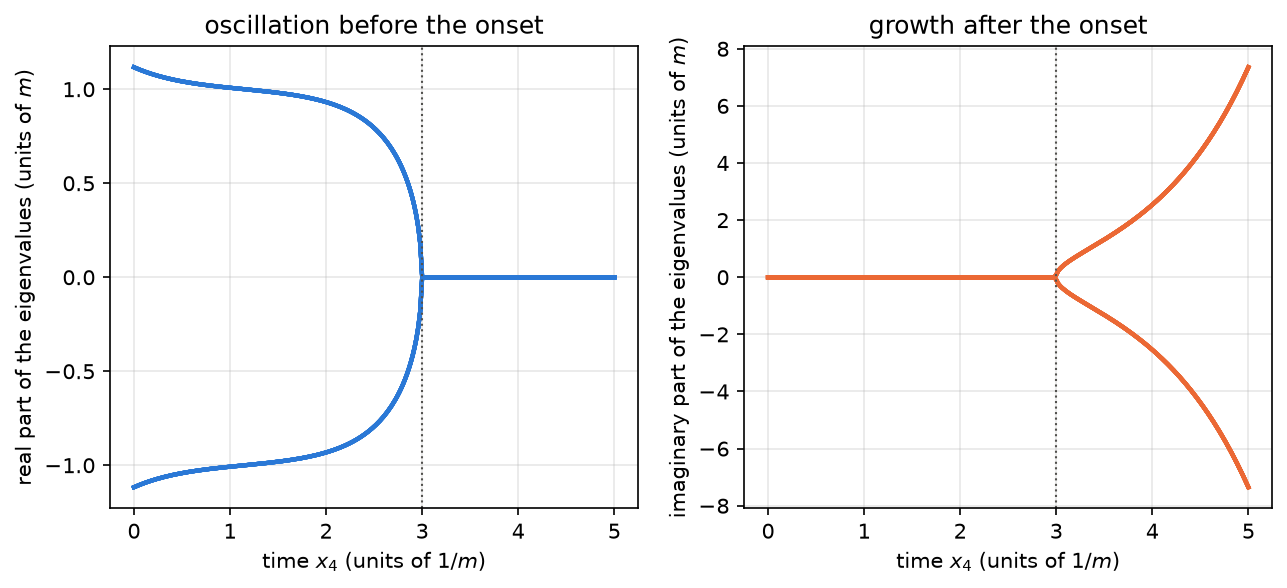

Figure 10f.2 saved as Revision/textbook/figures/10f_2_eigenvalues_along_history.png


In [8]:
scan_times = np.linspace(0.0, 5.0, 251)
real_parts, imaginary_parts, worst = [], [], 0.0
for x4 in scan_times:
    eigenvalues = np.linalg.eigvals(mode_hamiltonian(x4, 0.5, 0.05, 0.0))
    real_parts.append(np.sort(eigenvalues.real))
    imaginary_parts.append(np.sort(eigenvalues.imag))
    w2 = w_squared(x4, 0.5, 0.05, 0.0)
    if abs(w2) > 0.05:  # away from the onset
        w = np.sqrt(complex(w2))  # real, or i kappa after the onset
        predicted = np.array([w] * 8 + [-w] * 8)
        worst = max(worst,
                    np.max(np.abs(np.sort(eigenvalues.real) - np.sort(predicted.real))),
                    np.max(np.abs(np.sort(eigenvalues.imag) - np.sort(predicted.imag))))
report("largest difference from +-w(x4) away from the onset", f"{worst:.1e}")
check(worst < 1e-10, "at every instant the eigenvalues of h(x4) are +-w(x4), 8 each")

fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharex=True)
axes[0].plot(scan_times, np.array(real_parts), color=BLUE, linewidth=2)
axes[1].plot(scan_times, np.array(imaginary_parts), color=ORANGE, linewidth=2)
for ax, what in ((axes[0], "real part"), (axes[1], "imaginary part")):
    ax.axvline(onset, color=GREY, linestyle=":", linewidth=1)
    ax.set_xlabel("time $x_4$ (units of $1/m$)")
    ax.set_ylabel(f"{what} of the eigenvalues (units of $m$)")
axes[0].set_title("oscillation before the onset")
axes[1].set_title("growth after the onset")
save_figure(fig, "eigenvalues_along_history",
            "The 16 eigenvalues of the mode Hamiltonian $h(x_4)$ of a wave with the "
            "coordinate momenta $q_1 = 0.5$, $q_5 = 0.05$ at $y = 0$ along the "
            "deflating history $a_4 = x_4$ ($A = H = m = 1$): real parts (left, "
            "blue) and imaginary parts (right, orange), each curve carrying eight "
            "eigenvalues; horizontal axes: the time $x_4$ in units of $1/m$, "
            "vertical axes in units of $m$. Before the onset time $x_4^\\ast = "
            "2.996$ (dotted line) the eigenvalues are the real frequencies "
            "$\\pm w(x_4)$, which shrink as the extra-time frame momentum grows; at "
            "the onset they meet at 0 and then move onto the imaginary axis as "
            "$\\pm i\\kappa(x_4)$, and the growth rate $\\kappa$ keeps increasing.")

The next cell computes the Krein inertia of the eigenspace of $+w$ (for $w^2 < 0$:
of $+i\kappa$) at the same 251 times, with the projector and Gram-matrix method of
the first notebook of this chapter, skipping the times closer than 0.03 to the
onset. The Revision proof says: $(4, 4, 0)$ at every time before the onset,
$(0, 0, 8)$ (neutral) at every time after it. The cell checks this and draws it.

inertia before the onset: [(4, 4, 0)]; after the onset: [(0, 0, 8)]
PASS every instant before the onset: inertia (4, 4) (real frequency)
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_Krein_inertia_proof
PASS every instant after the onset: the eigenspace is Krein-neutral
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_complex_frequency_Krein_neutral


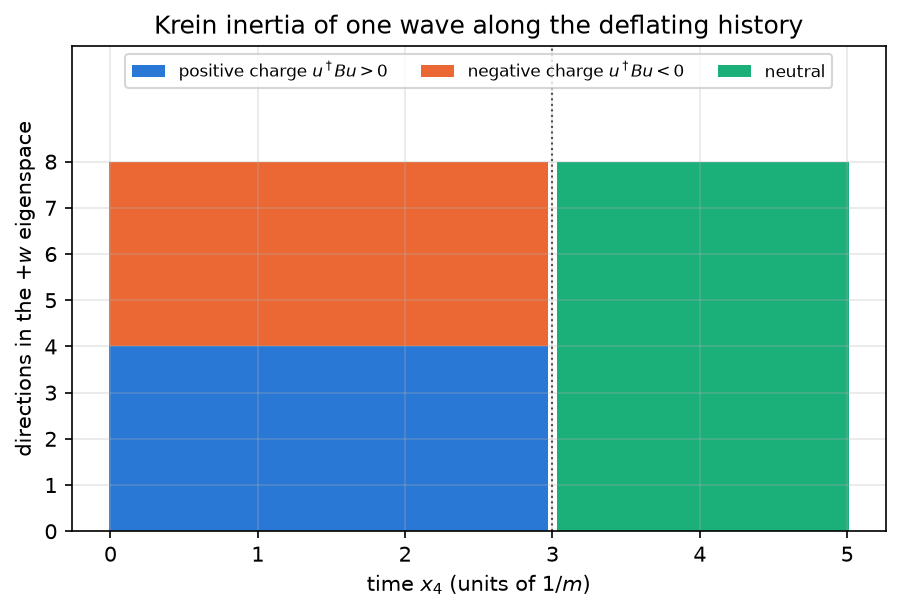

Figure 10f.3 saved as Revision/textbook/figures/10f_3_inertia_along_history.png


In [9]:
def orthonormal_basis(P):
    """Orthonormal columns that span the range of P (Gram-Schmidt, done twice)."""
    basis = []
    for column in P.T:
        v = column.astype(complex)
        for _ in range(2):  # the second pass removes rounding errors
            for e in basis:
                v = v - (e.conj() @ v) * e
        length = np.sqrt((v.conj() @ v).real)
        if length > 1e-8:
            basis.append(v / length)
    return np.array(basis).T


def eigenspace(h, w2, sign):
    """Orthonormal basis of the eigenspace of sign * w of h (w = sqrt(w2))."""
    w = np.sqrt(complex(w2))
    return orthonormal_basis((np.eye(16) + sign * h / w) / 2)


def krein_inertia(V):
    """(positive, negative, zero) eigenvalues of the Gram matrix V^dagger B V."""
    values = np.linalg.eigvalsh(V.conj().T @ B @ V)
    return (int(np.sum(values > 1e-8)), int(np.sum(values < -1e-8)),
            int(np.sum(np.abs(values) <= 1e-8)))


kept = [x4 for x4 in scan_times if abs(x4 - onset) > 0.03]
inertias = [krein_inertia(eigenspace(mode_hamiltonian(x4, 0.5, 0.05, 0.0),
                                     w_squared(x4, 0.5, 0.05, 0.0), +1))
            for x4 in kept]
before = {c for x4, c in zip(kept, inertias) if x4 < onset}
after = {c for x4, c in zip(kept, inertias) if x4 > onset}
say(f"inertia before the onset: {sorted(before)}; after the onset: {sorted(after)}")
check_record(before == {(4, 4, 0)},
             "every instant before the onset: inertia (4, 4) (real frequency)",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_Krein_inertia_proof")
check_record(after == {(0, 0, 8)},
             "every instant after the onset: the eigenspace is Krein-neutral",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_complex_frequency_Krein_neutral")

counts = np.array(inertias)
fig, ax = plt.subplots()
width = 0.0205  # a little wider than the step 0.02 between the times (no gaps)
ax.bar(kept, counts[:, 0], width=width, color=BLUE,
       label="positive charge $u^\\dagger B u > 0$")
ax.bar(kept, counts[:, 1], width=width, bottom=counts[:, 0], color=ORANGE,
       label="negative charge $u^\\dagger B u < 0$")
ax.bar(kept, counts[:, 2], width=width, bottom=counts[:, 0] + counts[:, 1],
       color=GREEN, label="neutral")
ax.axvline(onset, color=GREY, linestyle=":", linewidth=1)
ax.set_xlabel("time $x_4$ (units of $1/m$)")
ax.set_ylabel("directions in the $+w$ eigenspace")
ax.set_yticks(range(0, 9))
ax.set_ylim(0.0, 10.5)  # room for the legend above the bars
ax.set_title("Krein inertia of one wave along the deflating history")
ax.legend(loc="upper center", ncol=3, fontsize=8)
save_figure(fig, "inertia_along_history",
            "The Krein inertia of the eigenspace of $+w$ of the mode Hamiltonian "
            "of the wave $q_1 = 0.5$, $q_5 = 0.05$ ($y = 0$) at each time $x_4$ of "
            "the deflating history $a_4 = x_4$ (horizontal axis, units of $1/m$). "
            "Each thin bar splits the eight directions of the eigenspace (vertical "
            "axis) into positive charge (blue), negative charge (orange) and "
            "neutral (green). Before the onset time $x_4^\\ast = 2.996$ (dotted "
            "line) the split is 4 and 4 at every instant; after it the whole "
            "eigenspace is neutral. The deflation of the extra times moves the wave "
            "from the first kind to the second at a definite time.")

## 10. Every extra-time wave becomes Krein-neutral: the onset map

For $q_1 = 0.5$ and $y = 0$, the next cell computes the sign of $w^2$ on a grid of
241 times from 0 to 6 and 121 extra-time momenta $q_5$ from $10^{-3}$ to 1 (equally
spaced in $\log_{10} q_5$), checks that the sign agrees everywhere with the exact
onset time ($w^2 > 0$ exactly when $x_4 < x_4^\ast(q_5)$), computes the Krein
inertia directly at the grid points of every fourth momentum and every 60th time
(skipping those closer than 0.05 to the onset), and draws the map with the
onset curve and the five slices $a_{4,0}$ of the Kohn-Sham record. For every
$q_5 > 0$ the onset time is finite: no wave with extra-time momentum keeps a real
frequency for ever.

RESULT grid points sampled for the inertia = 153
RESULT onset time for q5 = 0.001 and for q5 = 1 = 6.9078 and 0.0941
PASS the map agrees with the exact onset; (4, 4) before it, neutral after it


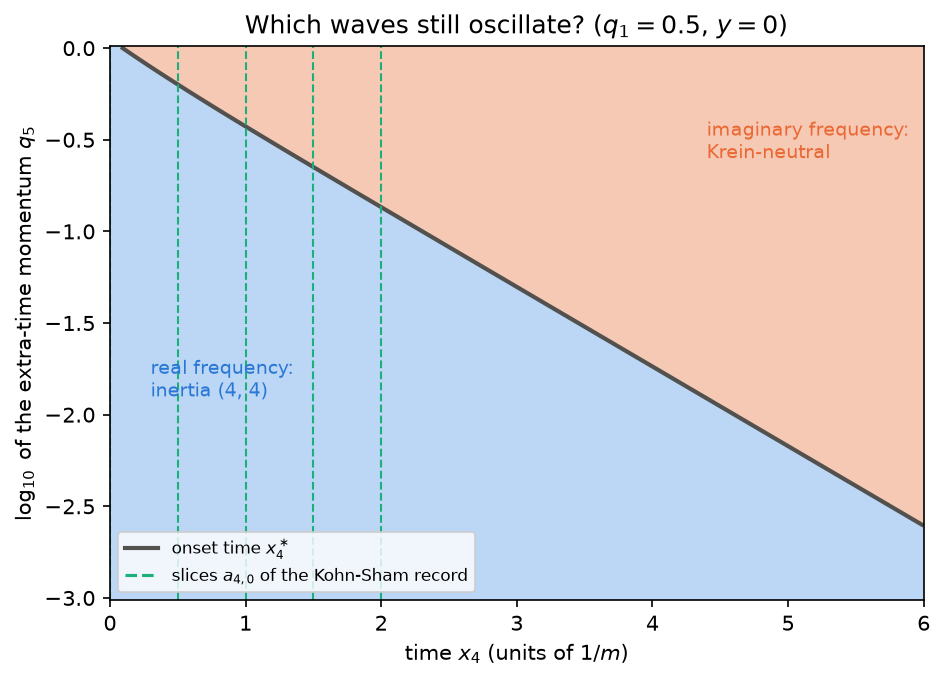

Figure 10f.4 saved as Revision/textbook/figures/10f_4_onset_map.png


In [10]:
map_times = np.linspace(0.0, 6.0, 241)
exponents = np.linspace(-3.0, 0.0, 121)  # log10 of q5
q5_values = 10.0 ** exponents
real_frequency = np.array([[w_squared(x4, 0.5, q5, 0.0) > 0 for x4 in map_times]
                           for q5 in q5_values])  # rows: q5, columns: x4
onsets = np.array([onset_time(0.5, q5, 0.0) for q5 in q5_values])
agree = np.array_equal(real_frequency, map_times[None, :] < onsets[:, None])
sampled, sample_ok = 0, True
for i in range(0, 121, 4):
    for j in range(0, 241, 60):
        x4, q5 = map_times[j], q5_values[i]
        if abs(x4 - onsets[i]) < 0.05:
            continue  # too close to the onset
        w2 = w_squared(x4, 0.5, q5, 0.0)
        found = krein_inertia(eigenspace(mode_hamiltonian(x4, 0.5, q5, 0.0), w2, +1))
        sample_ok = sample_ok and found == ((4, 4, 0) if w2 > 0 else (0, 0, 8))
        sampled += 1
report("grid points sampled for the inertia", sampled)
report("onset time for q5 = 0.001 and for q5 = 1",
       f"{onsets[0]:.4f} and {onsets[-1]:.4f}")
check(agree and sample_ok and np.all(np.isfinite(onsets)),
      "the map agrees with the exact onset; (4, 4) before it, neutral after it")

from matplotlib.colors import ListedColormap  # a colour scale with two colours

fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.pcolormesh(map_times, exponents, real_frequency.astype(float),
              cmap=ListedColormap(["#f6c9b5", "#bcd6f5"]), vmin=0, vmax=1,
              shading="nearest")
inside = onsets <= map_times[-1]  # the part of the onset curve inside the map
ax.plot(onsets[inside], exponents[inside], color=GREY, linewidth=2,
        label="onset time $x_4^\\ast$")
ax.set_xlim(map_times[0], map_times[-1])
for a4_slice in slices:
    ax.axvline(a4_slice / (A * H), color=GREEN, linestyle="--", linewidth=1)
ax.plot([], [], "--", color=GREEN, label="slices $a_{4,0}$ of the Kohn-Sham record")
ax.text(0.3, -1.9, "real frequency:\ninertia (4, 4)", color=BLUE, fontsize=9)
ax.text(4.4, -0.6, "imaginary frequency:\nKrein-neutral", color=ORANGE, fontsize=9)
ax.set_xlabel("time $x_4$ (units of $1/m$)")
ax.set_ylabel("$\\log_{10}$ of the extra-time momentum $q_5$")
ax.set_title("Which waves still oscillate? ($q_1 = 0.5$, $y = 0$)")
ax.legend(loc="lower left", fontsize=8)  # the lower left corner is all blue
ax.grid(False)
save_figure(fig, "onset_map",
            "For waves with the coordinate momenta $q_1 = 0.5$ and $q_5$ from "
            "$10^{-3}$ to 1 (vertical axis: $\\log_{10}q_5$) at the hidden position "
            "$y = 0$, along the deflating history $a_4 = x_4$ (horizontal axis: the "
            "time $x_4$ in units of $1/m$): light blue where the frequency is real "
            "(the eigenspaces have Krein inertia (4, 4)), light orange where it is "
            "imaginary (the eigenspaces are Krein-neutral and the wave grows). The "
            "grey curve is the exact onset time; the green dashed lines are the "
            "times of the five slices $a_{4,0} = 0$, 0.5, 1, 1.5, 2 of the Kohn-Sham "
            "record. As time goes on, smaller and smaller extra-time momenta cross "
            "into the orange region: the band of oscillating extra-time waves "
            "shrinks exponentially, and only the good sector $q_5 = 0$ stays blue "
            "for ever.")

## 11. The good sector along the history

In the good sector ($q_5 = 0$) the mode Hamiltonian of every instant is Hermitian
and commutes with $B$ (Section 7), with the energies $\pm E(x_4)$,

$$E(x_4) = \sqrt{m^2 + k_1^2} = \sqrt{m^2 + q_1^2e^{-2AHx_4 - 2Hy}},$$

which falls towards $m$ as 3-space inflates and its frame momentum shrinks. At each
instant the positive Fock space of the previous notebooks can be built with the
coefficients of that instant (an *instantaneous* Fock space): the filled sea has the
value $\sum_s v_s^\dagger hv_s = -8E(x_4)$, and a particle and an antiparticle have
the normal-ordered energies $u_s^\dagger hu_s = +E(x_4)$ and $-v_s^\dagger hv_s =
+E(x_4)$. The next cell checks, at the five slices of the Kohn-Sham record and for
four momenta $q_1 = 0.5, 1, 2, 4$ ($y = 0$): $h$ Hermitian, $Bh = hB$, eight
eigenvalues $+E$ and eight $-E$, the Krein inertia $(4, 4)$ of both eigenspaces, the
sea value $-8E$ and the quantum energies $+E$. Then it draws $E(x_4)$ and the sea
value.

q1    a4,0    E(x4)      sea value -8E
1.0   0.0    1.414214    -11.313708
1.0   0.5    1.169564     -9.356510
1.0   1.0    1.065521     -8.524169
1.0   1.5    1.024591     -8.196729
1.0   2.0    1.009116     -8.072930
4.0   0.0    4.123106    -32.984845
4.0   0.5    2.624132    -20.993060
4.0   1.0    1.779147    -14.233177
4.0   1.5    1.340371    -10.722964
4.0   2.0    1.137124     -9.096989
PASS good sector at all 5 slices: Hermitian, [B, h] = 0, +-E, (4, 4), sea -8E
     reproduces Revision/theory/reports/python-field-theory.json, check
    good_sector_spectrum_and_B_sectors


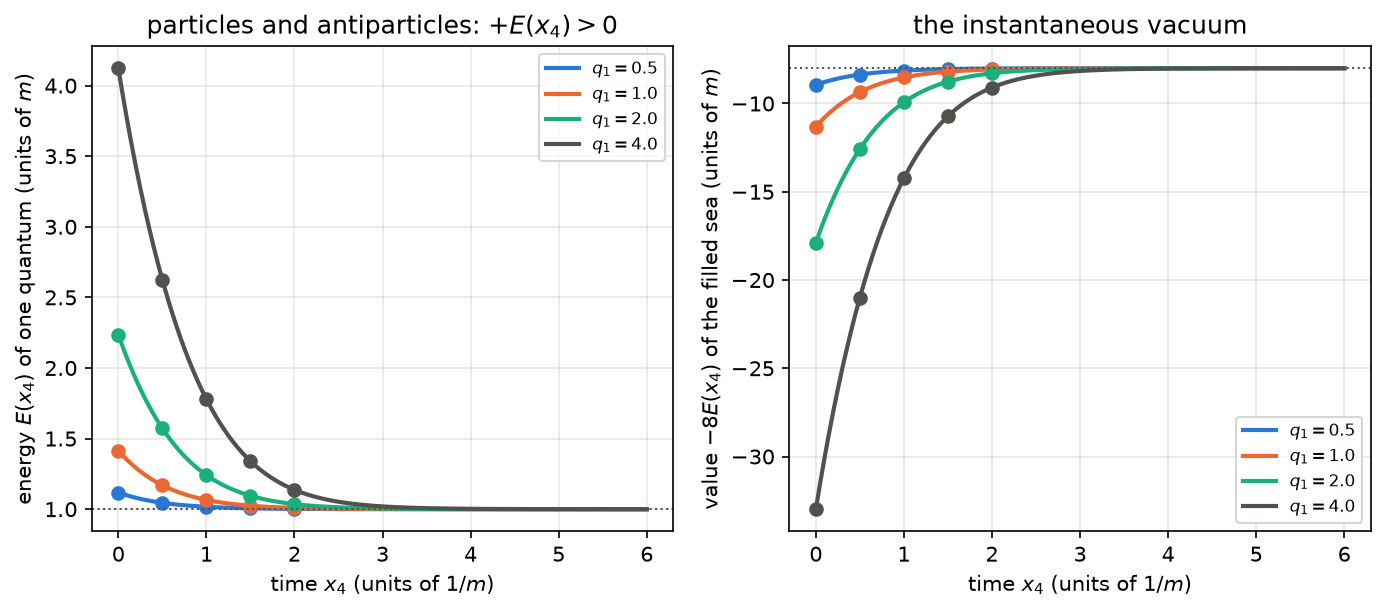

Figure 10f.5 saved as Revision/textbook/figures/10f_5_good_sector_energies.png


In [11]:
slice_ok, table = True, []
for q1 in (0.5, 1.0, 2.0, 4.0):
    for a4_slice in slices:
        x4 = a4_slice / (A * H)  # the time of the slice
        h = mode_hamiltonian(x4, q1, 0.0, 0.0)
        E = np.sqrt(w_squared(x4, q1, 0.0, 0.0))
        U_plus = eigenspace(h, E ** 2, +1)  # the 8 particle columns u_s
        V_minus = eigenspace(h, E ** 2, -1)  # the 8 antiparticle columns v_s
        sea = sum((v.conj() @ h @ v).real for v in V_minus.T)
        particle = [(u.conj() @ h @ u).real for u in U_plus.T]
        antiparticle = [-(v.conj() @ h @ v).real for v in V_minus.T]
        slice_ok = (slice_ok and np.allclose(h, h.conj().T) and np.allclose(B @ h, h @ B)
                    and U_plus.shape[1] == 8 and V_minus.shape[1] == 8
                    and krein_inertia(U_plus) == (4, 4, 0)
                    and krein_inertia(V_minus) == (4, 4, 0)
                    and abs(sea + 8 * E) < 1e-12
                    and np.allclose(particle, E) and np.allclose(antiparticle, E))
        table.append((q1, a4_slice, E, sea))
say("q1    a4,0    E(x4)      sea value -8E")
for q1, a4_slice, E, sea in table:
    if q1 in (1.0, 4.0):  # print two of the four momenta
        say(f"{q1:3.1f}   {a4_slice:3.1f}   {E:9.6f}   {sea:11.6f}")
check_record(slice_ok,
             "good sector at all 5 slices: Hermitian, [B, h] = 0, +-E, (4, 4), sea -8E",
             record="Revision/theory/reports/python-field-theory.json, check "
                    "good_sector_spectrum_and_B_sectors")

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for q1, colour in ((0.5, BLUE), (1.0, ORANGE), (2.0, GREEN), (4.0, GREY)):
    E_curve = np.sqrt(w_squared(curve_times, q1, 0.0, 0.0))
    axes[0].plot(curve_times, E_curve, color=colour, linewidth=2, label=f"$q_1 = {q1}$")
    axes[1].plot(curve_times, -8 * E_curve, color=colour, linewidth=2,
                 label=f"$q_1 = {q1}$")
    dots = [(a4_slice, E, sea) for q, a4_slice, E, sea in table if q == q1]
    axes[0].plot([d[0] for d in dots], [d[1] for d in dots], "o", color=colour)
    axes[1].plot([d[0] for d in dots], [d[2] for d in dots], "o", color=colour)
axes[0].axhline(mass, color=GREY, linestyle=":", linewidth=1)
axes[1].axhline(-8 * mass, color=GREY, linestyle=":", linewidth=1)
axes[0].set_ylabel("energy $E(x_4)$ of one quantum (units of $m$)")
axes[1].set_ylabel("value $-8E(x_4)$ of the filled sea (units of $m$)")
axes[0].set_title("particles and antiparticles: $+E(x_4) > 0$")
axes[1].set_title("the instantaneous vacuum")
for ax in axes:
    ax.set_xlabel("time $x_4$ (units of $1/m$)")
    ax.legend(fontsize=8)
save_figure(fig, "good_sector_energies",
            "The good sector along the deflating history $a_4 = x_4$ ($A = H = m = "
            "1$, $y = 0$) for the coordinate momenta $q_1 = 0.5$, 1, 2, 4 (blue, "
            "orange, green, grey); horizontal axes: the time $x_4$ in units of "
            "$1/m$. Left: the normal-ordered energy $E(x_4) = \\sqrt{m^2 + "
            "q_1^2e^{-2x_4}}$ of one particle or one antiparticle of the "
            "instantaneous Fock space, falling towards the mass $m$ (dotted line) "
            "as 3-space inflates; right: the value $-8E(x_4)$ of the filled sea, "
            "rising towards $-8m$ (dotted line). Vertical axes in units of $m$. "
            "Dots: computed from the eigenvectors "
            "at the five slices of the Kohn-Sham record. In the good sector every "
            "quantum has a positive energy at every time, and the Krein inertia "
            "stays (4, 4).")

## 12. The universes of masses $+m$ and $-m$ along the history

At every instant the mode Hamiltonian of the history is a mode Hamiltonian of the
first notebook of this chapter, so the identity $\Gamma h_m\Gamma = h_{-m}$ of the
Revision pairing record holds at every time ($\Gamma$ anticommutes with
$\gamma^{(x_4)}$ and commutes with $\gamma^{(x_4)}\gamma^{(x_1)}$ and
$\gamma^{(x_4)}\gamma^{(x_5)}$). The mass enters $w^2$ only as $m^2$, so the two
universes have the same frequencies, the same onset time and the same Krein inertia
at every instant. The next cell checks the identity at 25 times for the wave
$q_1 = 0.5$, $q_5 = 0.05$, and that the eigenvalues for $+m$ and $-m$ agree.

In [12]:
pair_ok, worst = True, 0.0
for x4 in np.linspace(0.0, 6.0, 25):
    h_plus = mode_hamiltonian(x4, 0.5, 0.05, 0.0, m=mass)
    h_minus = mode_hamiltonian(x4, 0.5, 0.05, 0.0, m=-mass)
    pair_ok = pair_ok and np.allclose(Gamma @ h_plus @ Gamma, h_minus, atol=1e-14)
    values_plus = np.linalg.eigvals(h_plus)
    values_minus = np.linalg.eigvals(h_minus)
    # compare the sorted real parts and the sorted imaginary parts separately
    worst = max(worst,
                np.max(np.abs(np.sort(values_plus.real) - np.sort(values_minus.real))),
                np.max(np.abs(np.sort(values_plus.imag) - np.sort(values_minus.imag))))
report("largest difference of the eigenvalues for +m and -m", f"{worst:.1e}")
check_record(pair_ok and worst < 1e-9,
             "Gamma h_m(x4) Gamma = h_-m(x4) at every time: same spectra and onset",
             record="Revision/pairing/reports/python-pairing.json, check "
                    "Q.one_particle_maps")

RESULT largest difference of the eigenvalues for +m and -m = 7.1e-15
PASS Gamma h_m(x4) Gamma = h_-m(x4) at every time: same spectra and onset
     reproduces Revision/pairing/reports/python-pairing.json, check Q.one_particle_maps


## 13. The last check

The last cell checks that all five figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [13]:
for name in ("10f_1_hermiticity_defect.png", "10f_2_eigenvalues_along_history.png",
             "10f_3_inertia_along_history.png", "10f_4_onset_map.png",
             "10f_5_good_sector_energies.png"):
    check(output_file(f"{FIGURE_FOLDER}/{name}").is_file(),
          f"the figure file {name} exists")
all_checks_passed()

PASS the figure file 10f_1_hermiticity_defect.png exists
PASS the figure file 10f_2_eigenvalues_along_history.png exists
PASS the figure file 10f_3_inertia_along_history.png exists
PASS the figure file 10f_4_onset_map.png exists
PASS the figure file 10f_5_good_sector_energies.png exists
ALL 19 CHECKS PASSED (notebook 10f)


## 14. What this notebook showed

- REPRODUCED from the Revision records: the deflating history $a_4 = AHx_4$ with
  $A = H = m = 1$ and its status, and the scale factors of the author's metric; a
  wave $e^{i(q_1x_1 + q_5x_5)}$ has the frame momenta $k_1 = q_1e^{-a_4}
  \sin^{-1/6}z$ (shrinking: 3-space inflates) and $k_5 = q_5e^{a_4}\sin^{-1/6}z$
  (growing: the extra times deflate).
- PROVED (exactly, at every instant of the local-frame model): $h(x_4)^2 =
  w(x_4)^2I_{16}$ with $w^2 = m^2 + k_1^2 - k_5^2$; the anti-Hermitian part of
  $h(x_4)$ has the size $k_5$ and the mixing of the two eigenspaces of $B$ the size
  $2k_5$, both growing like $e^{a_4}$; in the good sector $h(x_4)$ is Hermitian and
  commutes with $B$ at every time.
- PROVED (exactly): every wave with $q_5 \neq 0$ reaches the onset time
  $x_4^\ast = \ln X^\ast/(2AH)$ and grows afterwards. COMPUTED: the onset of the
  wave $q_1 = 0.5$, $q_5 = 0.05$ is $x_4^\ast = 2.996$; the recorded sample $m = 1$,
  $k_5 = 2$ (eigenvalues $\pm i\sqrt3$) is the instant $x_4 = \ln 40$ of the wave
  $q_5 = 0.05$; the Krein inertia is $(4, 4)$ at every instant before the onset and
  the eigenspaces are Krein-neutral at every instant after it; the band of
  oscillating extra-time waves shrinks exponentially, and only the good sector
  keeps real frequencies for ever.
- COMPUTED (at the five slices of the Kohn-Sham record): in the good sector the
  instantaneous Fock space has the sea value $-8E(x_4)$ and quanta of energy
  $+E(x_4) > 0$, with $E$ falling towards $m$.
- PROVED (at every instant): the masses $+m$ and $-m$ have identical one-particle
  spectra, onset times and Krein inertia.
- ASSUMED: the history $a_4 = AHx_4$ is a prescribed background, not a solution of
  the field equations for $a_4$ with this field as the source; the local-frame model
  evaluates the coefficients at one instant and one hidden position and leaves out
  the hidden-direction terms.
- OPEN (not computed here): the evolution of the quantum state through the changing
  background (whether the instantaneous vacuum of one time contains quanta of a
  later time); a positive state space for the extra-time sector, whose waves all
  become Krein-neutral.